In [4]:
# Import necessary libraries
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer

In [ ]:
# Define file paths
input_file = r"C:\Users\himel\Downloads\flares1981-2017 (1).txt"
output_file = r"C:\Users\himel\Downloads\solarflares1981-2017.csv"

In [187]:
def parse_line(line):
    match = re.match(r"""
        (?P<flare_number>\d{11})\s+         # Flare Number (11 digits)
        (?P<start_time>\d{4})\s+           # Start Time (4 digits)
        (?P<end_time>\d{4})\s+             # End Time (4 digits)
        (?P<peak_time>\d{4})\s+            # Peak Time (4 digits)
        (?P<region>[NESW\d\+-]*?)\s+ # region (optional)
        (?P<class>[A-Z])\s+                 # Class (single letter)
        (?P<intensity>\d+)\s+               # Intensity (numeric)
        (?P<observatory>\w+)\s*            # Observatory (e.g., GOES)
        (?P<extra>.*)                       # Extra data (if any)
    """, line, re.VERBOSE)
    
    if match:
        return match.groupdict()  # Return a dictionary of matched groups
    return {}  # Return an empty dictionary if the line doesn't match

In [188]:
data = []
with open(input_file, "r") as file:
    for line in file:
        if line.strip():
            parsed = parse_line(line)
            data.append(parsed)

In [ ]:
# Create a DataFrame and save to CSV
df = pd.DataFrame(data)
df_cleaned = df.dropna(how='all')
df_cleaned.to_csv(output_file, index=False)

In [ ]:
# Load the cleaned dataset
cleaned_file_path = r"C:\Users\himel\Downloads\solarflares1981-2017cleaned.csv"
df = pd.read_csv(cleaned_file_path)

In [ ]:
df = pd.read_csv(r"C:\Users\himel\Downloads\solarflares1981-2017.csv")

In [193]:
df.head()

,flare_number,start_time,end_time,peak_time,region,class,intensity,observatory,extra
0,31777810102,441,446,444,NaN,C,18,GOES,NaN
1,31777810102,955,1004,1000,NaN,C,18,GOES,NaN
2,31777810103,1025,1036,1030,NaN,C,51,GOES,NaN
3,31777810103,1549,1558,1553,NaN,C,22,GOES,2857
4,31777810103,1837,1845,1842,NaN,C,22,GOES,NaN


In [194]:
#changeing the data type
df['start_time'] = pd.to_datetime(df['start_time'], unit='s')
df['end_time'] = pd.to_datetime(df['end_time'], unit='s')
df['peak_time'] = pd.to_datetime(df['peak_time'], unit='s')

In [195]:
df['flare_number'] = df['flare_number'].astype(str)

# Define extract_date function with improved error handling
def extract_date(flare_number):
    # Ensure we're working with a valid date format
    date_str = str(flare_number).split('.')[0][-6:]  # Strip out any decimal point
    year_prefix = '19' if int(date_str[:2]) >= 71 else '20'
    
    try:
        # Convert the extracted date to a valid datetime object
        return pd.to_datetime(f"{year_prefix}{date_str}", format='%Y%m%d', errors='raise')
    except Exception as e:
        # If there's an error, return NaT (Not a Time) to handle invalid data gracefully
        return pd.NaT

In [ ]:
df['date'] = df['flare_number'].apply(extract_date)

# Save cleaned data to CSV
cleaned_file_path = r'C:\Users\salih\Downloads\labeled_flares.csv'
df.to_csv(cleaned_file_path, index=False)

In [197]:
df['date'] = pd.to_datetime(df['date'])

In [198]:
#calculating flare duration
df['flare_duration'] = (df['end_time'] - df['start_time']).dt.total_seconds()

In [199]:
#calculating time to peak
df['time_to_peak'] = (df['peak_time'] - df['start_time']).dt.total_seconds()

In [200]:
#calculating start hour, start day of week, start month
df['start_hour'] = df['start_time'].dt.hour
df['start_dayofweek'] = df['start_time'].dt.dayofweek
df['start_month'] = df['start_time'].dt.month

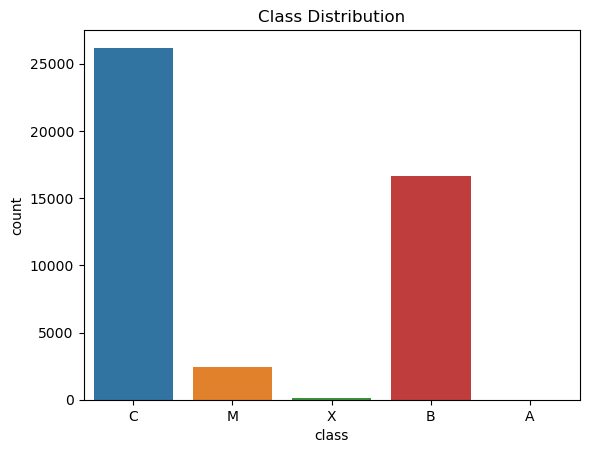

In [201]:
# class distribution plot
sns.countplot(data=df, x='class')
plt.title('Class Distribution')
plt.show()

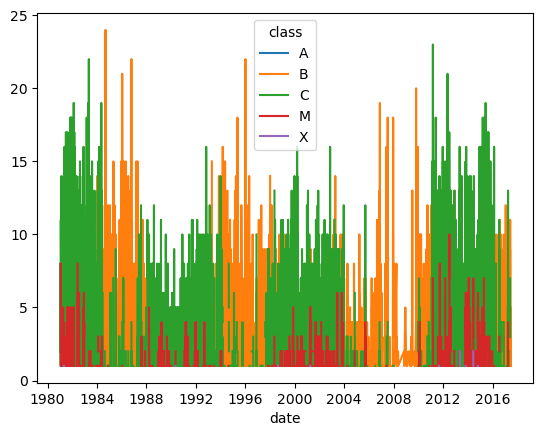

In [202]:
#class trend based on time
df.groupby(df['date'].dt.date)['class'].value_counts().unstack().plot(kind='line')
plt.show()

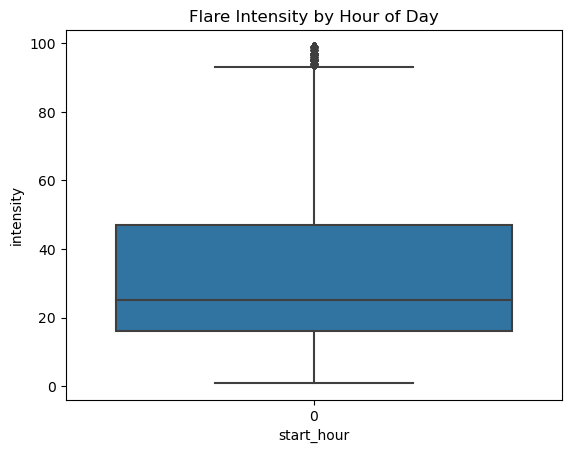

In [204]:
#flare intensity by hour of the day
sns.boxplot(data=df, x='start_hour', y='intensity')
plt.title('Flare Intensity by Hour of Day')
plt.show()

In [205]:
df.head()

,flare_number,start_time,end_time,peak_time,region,class,intensity,observatory,extra,date,flare_duration,time_to_peak,start_hour,start_dayofweek,start_month
0,31777810102,1970-01-01 00:07:21,1970-01-01 00:07:26,1970-01-01 00:07:24,NaN,C,18,GOES,NaN,1981-01-02,5.0,3.0,0,3,1
1,31777810102,1970-01-01 00:15:55,1970-01-01 00:16:44,1970-01-01 00:16:40,NaN,C,18,GOES,NaN,1981-01-02,49.0,45.0,0,3,1
2,31777810103,1970-01-01 00:17:05,1970-01-01 00:17:16,1970-01-01 00:17:10,NaN,C,51,GOES,NaN,1981-01-03,11.0,5.0,0,3,1
3,31777810103,1970-01-01 00:25:49,1970-01-01 00:25:58,1970-01-01 00:25:53,NaN,C,22,GOES,2857,1981-01-03,9.0,4.0,0,3,1
4,31777810103,1970-01-01 00:30:37,1970-01-01 00:30:45,1970-01-01 00:30:42,NaN,C,22,GOES,NaN,1981-01-03,8.0,5.0,0,3,1


In [207]:
df_new = df[['flare_duration', 'time_to_peak', 'intensity']]

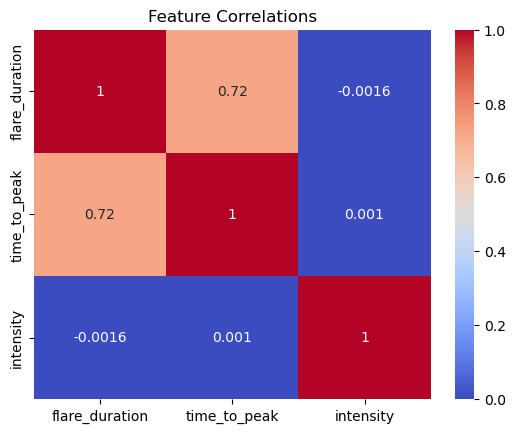

In [208]:
corr = df_new.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlations')
plt.show()

In [210]:
df['solar_coords'] = pd.to_numeric(df['region'], errors='coerce')


In [211]:
df.head()

,flare_number,start_time,end_time,peak_time,region,class,intensity,observatory,extra,date,flare_duration,time_to_peak,start_hour,start_dayofweek,start_month,solar_coords
0,31777810102,1970-01-01 00:07:21,1970-01-01 00:07:26,1970-01-01 00:07:24,NaN,C,18,GOES,NaN,1981-01-02,5.0,3.0,0,3,1,NaN
1,31777810102,1970-01-01 00:15:55,1970-01-01 00:16:44,1970-01-01 00:16:40,NaN,C,18,GOES,NaN,1981-01-02,49.0,45.0,0,3,1,NaN
2,31777810103,1970-01-01 00:17:05,1970-01-01 00:17:16,1970-01-01 00:17:10,NaN,C,51,GOES,NaN,1981-01-03,11.0,5.0,0,3,1,NaN
3,31777810103,1970-01-01 00:25:49,1970-01-01 00:25:58,1970-01-01 00:25:53,NaN,C,22,GOES,2857,1981-01-03,9.0,4.0,0,3,1,NaN
4,31777810103,1970-01-01 00:30:37,1970-01-01 00:30:45,1970-01-01 00:30:42,NaN,C,22,GOES,NaN,1981-01-03,8.0,5.0,0,3,1,NaN


In [212]:
from sklearn.preprocessing import LabelEncoder

df['region'] = LabelEncoder().fit_transform(df['region'])
df['observatory'] = LabelEncoder().fit_transform(df['observatory'])

In [214]:
# Historical average intensity by region
historical_intensity = df.groupby('region')['intensity'].mean().reset_index()
historical_intensity.rename(columns={'intensity': 'avg_intensity'}, inplace=True)

In [215]:
df = pd.merge(df, historical_intensity, on='region')

In [234]:
# drop start_time, end_time, peak_time, extra, flarenumber column
df_new = df.drop(columns=['start_time', 'end_time', 'peak_time', 'extra', 'flare_number',
                         'date'])

In [235]:
df_new.head(17)

,region,class,intensity,observatory,flare_duration,time_to_peak,start_hour,start_dayofweek,start_month,solar_coords,avg_intensity
0,6151,C,18,3,5.0,3.0,0,3,1,NaN,33.953952
1,6151,C,18,3,49.0,45.0,0,3,1,NaN,33.953952
2,6151,C,51,3,11.0,5.0,0,3,1,NaN,33.953952
3,6151,C,22,3,9.0,4.0,0,3,1,NaN,33.953952
4,6151,C,22,3,8.0,5.0,0,3,1,NaN,33.953952
5,6151,C,19,3,15.0,3.0,0,3,1,NaN,33.953952
6,6151,C,13,3,8.0,4.0,0,3,1,NaN,33.953952
7,6151,C,19,3,5.0,3.0,0,3,1,NaN,33.953952
8,6151,C,23,3,10.0,4.0,0,3,1,NaN,33.953952
9,6151,C,20,3,8.0,3.0,0,3,1,NaN,33.953952


In [249]:
# feature selection and split data into test and train dataset
from sklearn.model_selection import train_test_split

X = df_new.drop(columns=['class'])  # Features
y = df_new['class']  # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [250]:
import numpy as np
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Fit Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Print results
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['solar_coords']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\impute\_base.py:555: UserWarning: Skipping features without any observed values: ['solar_coords']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

[[   0    2    0    0    0]
 [   0 1326 2034    7    0]
 [   0  619 4550   23    0]
 [   0   33  466    6    0]
 [   0    0   18    0    0]]
              precision    recall  f1-score   support

           A       0.00      0.00      0.00         2
           B       0.67      0.39      0.50      3367
           C       0.64      0.88      0.74      5192
           M       0.17      0.01      0.02       505
           X       0.00      0.00      0.00        18

    accuracy                           0.65      9084
   macro avg       0.30      0.26      0.25      9084
weighted avg       0.63      0.65      0.61      9084



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [251]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       0.00      0.00      0.00         2
           B       0.60      0.55      0.57      3367
           C       0.67      0.76      0.71      5192
           M       0.28      0.09      0.14       505
           X       0.00      0.00      0.00        18

    accuracy                           0.64      9084
   macro avg       0.31      0.28      0.28      9084
weighted avg       0.62      0.64      0.63      9084



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [252]:
X_encoded = pd.get_dummies(X)
feature_names = X_encoded.columns.tolist()

In [254]:
if len(importances) == len(feature_names):
    sns.barplot(x=importances, y=feature_names)
    plt.title('Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.show()
else:
    print("Mismatch between feature importances and feature names lengths.")
    print("Number of importances:", len(importances))
    print("Number of feature names:", len(feature_names))


Mismatch between feature importances and feature names lengths.
Number of importances: 9
Number of feature names: 10


In [258]:
df['date'] = df['flare_number'].apply(extract_date)

In [259]:
flare_counts = df.groupby('date').size().reset_index(name='flare_count')
flare_counts['all_clear'] = flare_counts['flare_count'] == 0

In [260]:
# Prepare data for prediction
flare_counts['target'] = flare_counts['all_clear'].astype(int)
X = flare_counts[['flare_count']]
y = flare_counts['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [261]:
# Train a Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [262]:
# Train a Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [263]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')

Accuracy: 1.0
Confusion Matrix:
[[1954]]


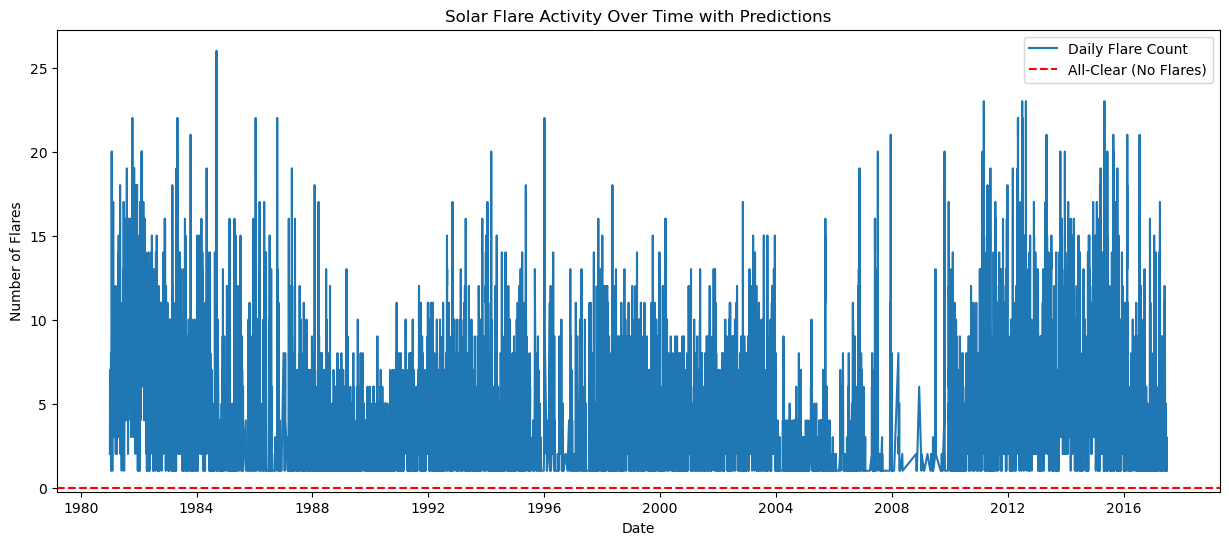

In [264]:
# Visualize the prediction results
plt.figure(figsize=(15, 6))
plt.plot(flare_counts['date'], flare_counts['flare_count'], label='Daily Flare Count')
plt.axhline(0, color='red', linestyle='--', label='All-Clear (No Flares)')
plt.xlabel('Date')
plt.ylabel('Number of Flares')
plt.title('Solar Flare Activity Over Time with Predictions')
plt.legend()
plt.show()

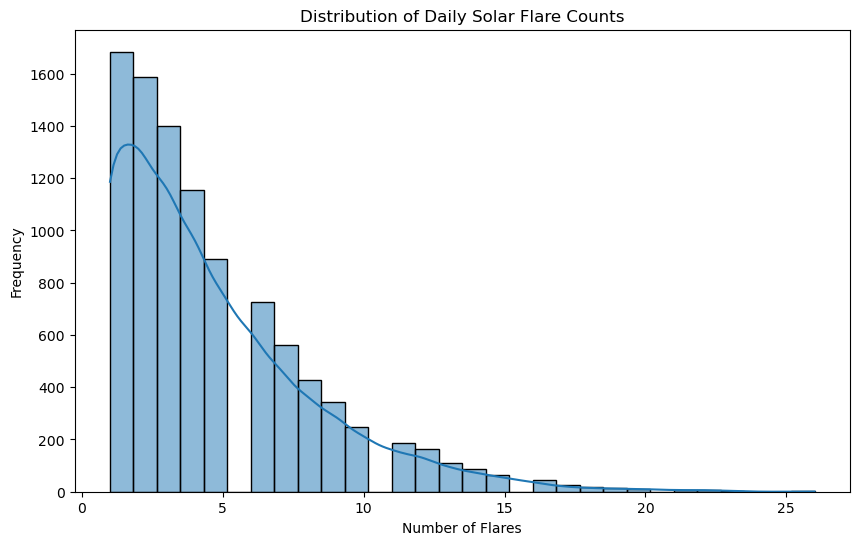

In [265]:
# Histogram of flare occurrences
plt.figure(figsize=(10, 6))
sns.histplot(flare_counts['flare_count'], bins=30, kde=True)
plt.title('Distribution of Daily Solar Flare Counts')
plt.xlabel('Number of Flares')
plt.ylabel('Frequency')
plt.show()

In [266]:
# Calendar heatmap of all-clear days
flare_counts['year'] = flare_counts['date'].dt.year
flare_counts['month'] = flare_counts['date'].dt.month

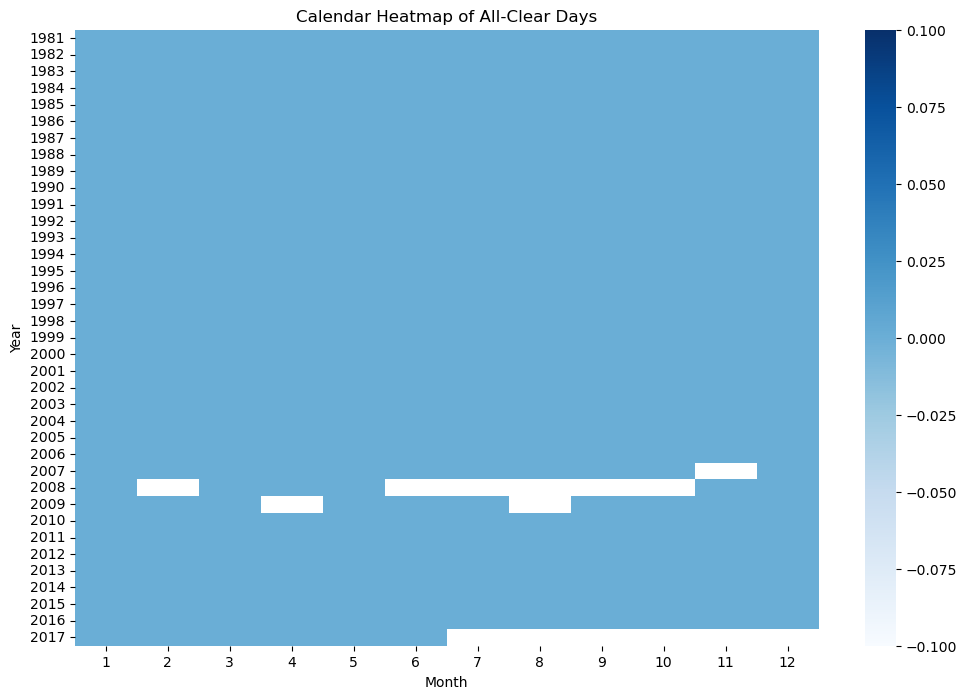

In [267]:
plt.figure(figsize=(12, 8))
sns.heatmap(flare_counts.pivot_table(values='all_clear', index='year', columns='month', aggfunc='sum'), cmap='Blues')
plt.title('Calendar Heatmap of All-Clear Days')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

In [268]:
# Calendar heatmap of all-clear days
flare_counts['year'] = flare_counts['date'].dt.year
flare_counts['month'] = flare_counts['date'].dt.month

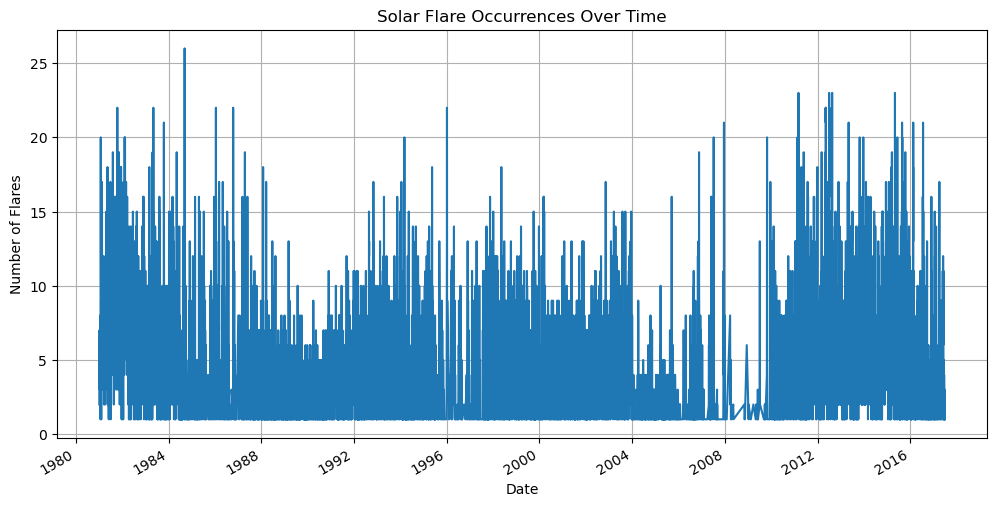

In [269]:
# Time-Series Analysis
plt.figure(figsize=(12, 6))
df['date'].value_counts().sort_index().plot(kind='line', title='Solar Flare Occurrences Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Flares')
plt.grid(True)
plt.show()

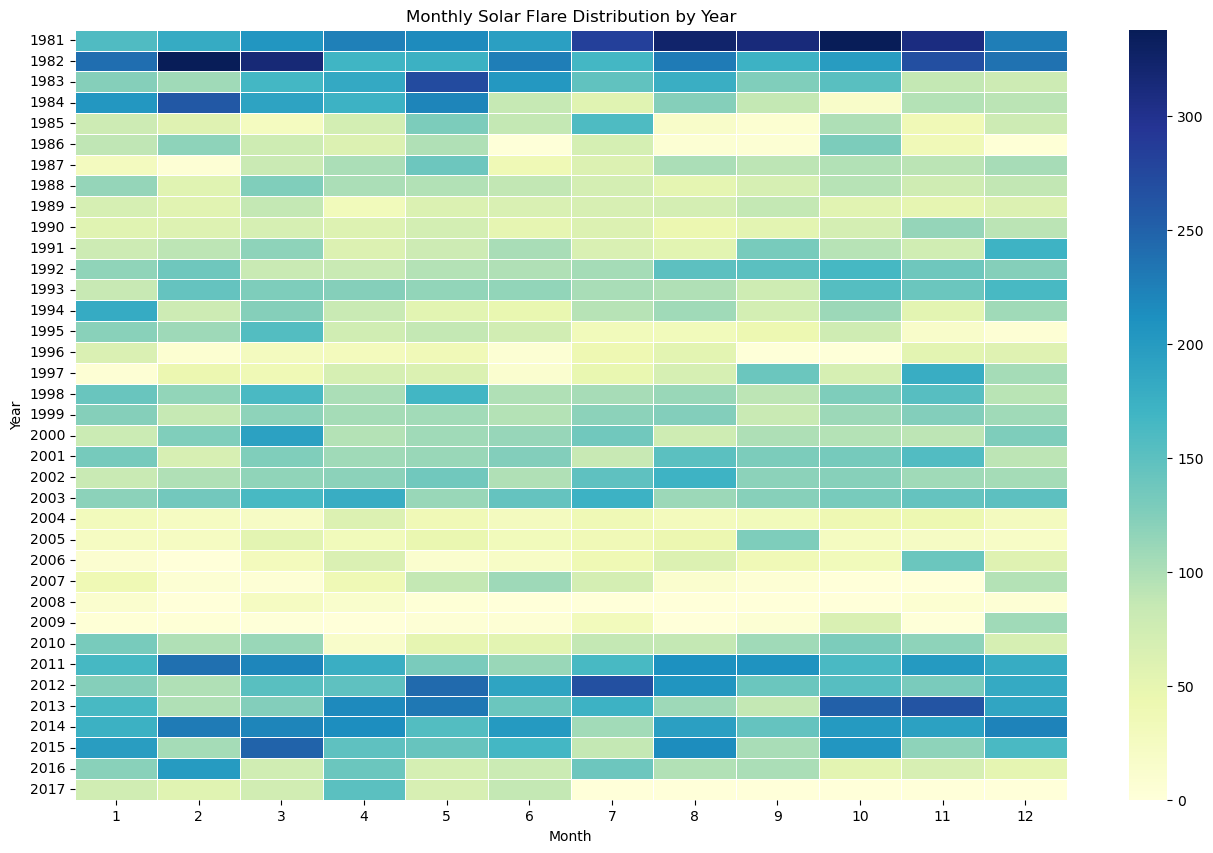

In [270]:
# Heatmap of Monthly Distribution by Year
df['year'] = df['date'].dt.year
df['month_num'] = df['date'].dt.month
heatmap_data = df.groupby(['year', 'month_num']).size().unstack(fill_value=0)
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.5, annot=False)
plt.title('Monthly Solar Flare Distribution by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()